AI 모델의 성능을 평가하는 과정은 매우 중요, 학습한 모델이 얼마나 잘 작동하는 지를 확인하고, 이를 통해 개선 방향을 설정할 수 있기 때문, 이번 장에서는 분류 모델과 회귀 모델의 평가 방법을 쉽게 이해할 수 있도록 설명 

1. 분류 모델 평가 방법
    1. 혼동 행렬(Confusion Matrix)
        - 혼동 행렬이란? 분류 모델의 예측 결과를 실제 정답과 비교하여 예측의 정확성과 오류를 한눈에 볼 수 있도록 정리한 표
            - 혼동 행렬의 구조
                - TP(True Positive): 실제 값이 양성이고 모델도 양성으로 예측
                    - ex> "스팸 메일"을 스팸으로 정확히 예측
                - TN(True Negative): 실제 값이 부정이고 모델도 부정으로 예측
                    - ex> "일반 메일"을 일반으로 정확히 예측
                - FP(False Positive): 실제 값은 부정인데 모델이 양성으로 잘못 예측
                    - ex> "일반 메일"을 스팸으로 잘못 예측
                - FN(False Negative): 실제 값이 양성이고 모델이 부정으로 잘못 예측
                    - ex> "스팸 메일"을 일반으로 정확히 예측

                    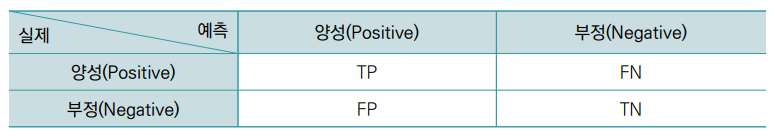

            - 쉽게 이해하기: 혼동 행렬은 시험 점수표와 비슷
                - TP와 TN: 시험 문제를 맞힌 부분
                - FP와 FN: 시험 문제를 틀린 부분
                - 혼동 행렬은 모델의 오류를 분석하고 개선점을 찾는 데 유용

    2. 정확도와 F1-score
        - 정확도(Accuracy): 정확도는 모델이 전체 데이터 중에서 정답을 얼마나 맞췄는지를 비율로 나타냄, 쉽게 말해 시험에서 몇 문제를 맞췄는지를 확인하는 것과 같음

            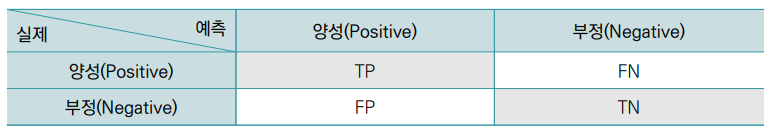

            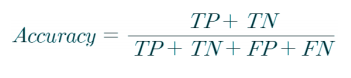

        - TP (True Positive): 맞게 양성으로 예측 (ex> 스팸 메일을 스팸으로 맞춤)
        - TN (True Nagative): 맞게 부정으로 예측 (ex> 일반 메일을 일반으로 맞춤)
        - FP (False Positive): 틀리게 양성으로 예측 (ex> 일반 메일을 스팸으로 잘못 판단)
        - FN (False Nagative): 틀리게 부정으로 예측 (ex> 스팸 메일을 일반 메일로 잘못 판단)

        - 정확도의 문제: 데이터가 불균형하면 정확한 성능을 평가할 수 없음
        - 예시 1
            - 실제 데이터: 100개의 메일 중 95개는 "일반 메일", 5개는 "스팸"
            - 예측 모델: 모든 메일을 "일반 메일"로 예측
            - TP: 0개 맞음, TN: 95개 맞음, FP: 0개 틀림, FN: 5개 틀림
            - 정확도 계산
                - Accuracry = (TP + TN) / 전체 = (0 + 95) / 100 = 95%
            - 정확도가 95%로 매우 높아 보이지만 사실 모델은 "스팸 메일"을 하나도 찾지 못함 -> 정확도 만으로는 모델 성능을 완전히 알 수 없음
        - F1-score: 정밀도와 재현율 균형
            - F1-score는 정밀도(Precision)와 재현율(Recall)을 동시에 고려한 지표
                - 정밀도(Precision): "스팸"이라고 예측한 메일 중에서 실제로 스팸인 메일의 비율
                - Precision = TP / (TP + FP) = 7 / (7 + 3) = 70%

                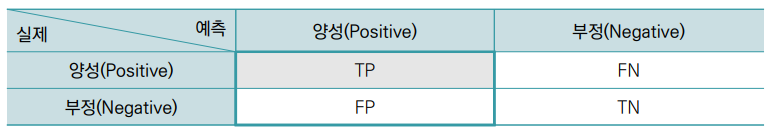

                - 재현율(Recall): 실제 "스팸" 메일 중에서 "스팸"이라고 제대로 예측한 비율
                    - Recall = TP / (TP + FN) = 7 / (7 + 5) = 58.3%

                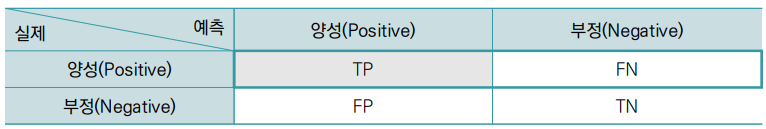

                - F1-score 계산: 정밀도와 재현율의 조화 평균
                    - 2 x ((Precision x Recall) / (Precision + Recall)) = 2 x ((0.7 x 0.583) / (0.7 + 0.583)) ≈ 63.6%

    3. 정밀도(Precision)와 재현율(Recall)
        - 정밀도(Precision)와 재현율(Recall)을 선택해서 사용하는 상황은 문제의 중요도와 우선순위에 따라 달라짐, 아래에서 두 개념의 차이를 구체적으로 설명하고, 언제 정밀도를 더 중요하게 사용해야 하고, 언제 재현율을 우선시해야 하는 지 예시를 들어 쉽게 설명
            - 언제 정밀도응 우선시 해야 하는 가?
                - "잘못된 양성 예측(FP)"이 큰 문제를 일으키는 경우
                - 즉, 양성으로 잘못 예측하면 큰 비용이나 심각한 결과를 초래할 때 정밀도가 중요
                - 예시 1: 스팸 필터링
                    - 문제: 이메일이 "스팸"인지 "일반"인지 예측하는 문제
                    - 위험 요소: 일반 이메일을 "스팸"으로 잘못 분류하면(FN), 사용자가 중요한 이메일을 놓칠 수 있음
                    - 우선순위: 거짓 양성(FP)을 줄여야 하므로 정밀도가 중요
                - 예시 2: 추천 시스템
                    - 문제: 쇼핑몰에서 고객이 좋아할 상품을 추천
                    - 위험 요소: 고객이 관심없는 상품을 추천하면(FP), 추천의 신뢰도가 떨어지고 클릭율이 낮아짐
                    - 우선순위: 추천 결과의 품질이 중요하므로 정밀도를 높이는 것이 유리

            - 언제 재현율을 우선시 해야 하는 가?
                - "거짓 부정(FN)"이 큰 문제를 일으키는 경우
                - 즉, 양성을 놓쳐서는 안 되는 상황에서는 재현율이 중요
                - 예시 1: 암 환자 진단
                    - 문제: 환자가 암인지 아닌지 예측하는 문제
                    - 위험 요소: 실제 암 환자를 "암이 아니다(FN)"라고 잘못 진단하면 환자가 치룔르 받지 못하는 심각한 결과를 초래
                    - 우선순위: 암 환자를 놓치지 않아야 하므로 재현율이 중요
                - 예시 2: 침입탐지 시스템
                    - 문제: 네트워크 보안 시스템에서 해커의 침입을 탐지
                    - 위험 요소: 실제 해커의 침입(FN)을 놓치면 시스템이 해킹당할 위험이 커짐
                    - 우선순위: 침입을 놓치지 않도록 재현율을 높이는 것이 중요

            - 정밀도와 재현율의 균형: 정밀도와 재현율은 서로 상충하는 관계에 있음
                - 정밀도를 높이면, 양성을 더 신중하게 예측하기 때문에 재현율이 낮아질 가능성이 있음
                - 재현율을 높이면 더 많은 데이터를 양성으로 예측하려고 하므로 정밀도가 낮아질 가능성이 있음
                - 균형을 맞추는 방법: F1-score
                    - 정밀도와 재현율이 모두 중요한 경우, 두 지표의 균형을 평가하는 F1-score를 사용

    4. ROC 와 AUC
        - ROC(Receiver Operation Characteristic)와 AUC(Area Under Curve)는 분류 모델의 성능을 평가하는 중요한 방법, 특히 모델이 양성(긍정) 데이터를 얼마나 잘 구별하는 지 시각적으로 확인할수 있게 해줌
        - 아래에서는 ROC와 AUC의 계산 원리부터 구체적인 예시까지 설명 진행

            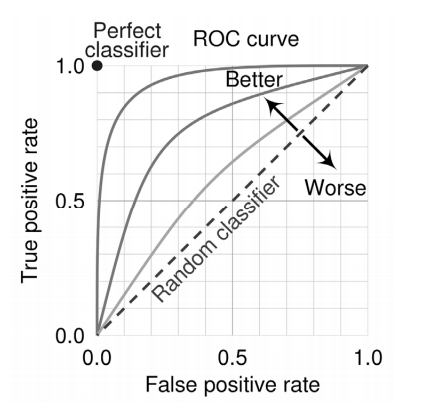

    5. ROC 곡선이란?
        - ROC 곡선의 역할
            - ROC 곡선은 모델의 재현율(Recall)과 거짓 긍정 비율(False Positive Rate) 사이의 관계를 보여줌
                - 재현율(Recall): 실제 양성(긍정) 데이터를 얼마나 잘 찾아냈는가?
                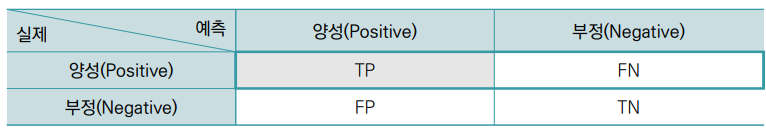

                - 거짓 긍정 비율(FPR): 실제 음성(부정) 데이터를 얼마나 잘못 긍정으로 예측했는가?
                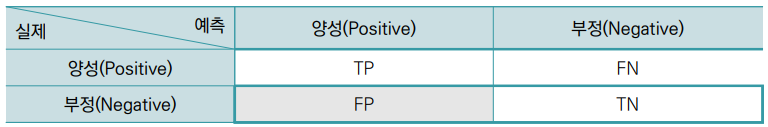

            - ROC 곡선의 X축과 Y축은 다음과 같음
                - X축(FPR): 잘못된 긍정 예측 비율(False Positive Rate)
                - Y축(Recall): 올바른 긍정 예측 비율(True Positive Rate) 
            - 임계값(Threshold)을 조정하면서 FPR과 Recall의 조합이 어떻게 변하는지 나타낸 그래프가 ROC 곡선
                - 임계값은 모델이 데이터를 긍정(1)으로 예측할 지, 부정(0)으로 예측할 지 결정하는 기준
                    - ex> 임계값 = 0.5 -> 50% 이상이면 긍정(1), 미만이면 부정(0)

        - 예시로 이해하기
            - 암 진단 모델이; 있거, 데이터 10개에 대해 예측 확률 값을 제공
            - 모델이 각 데이터가 암일 확률을 계산했다고 가정
            
                | 데이터 | 실제 값(정답) | 모델 확률 예측 | 
                | --- | --- | --- |
                | 1 | 양성(암) | 0.9 |
                | 2 | 음성(정상) | 0.8 |
                | 3 | 양성(암) | 0.7 |
                | 4 | 음성(정상) | 0.6 |
                | 5 | 양성(암) | 0.55 |
                | 6 | 음성(정상) | 0.45 |
                | 7 | 양성(암) | 0.4 |
                | 8 | 음성(정상) | 0.3 |
                | 9 | 음성(정상) | 0.2 |
                | 10 | 양성(암) | 0.1 |

            - 임계값에 따른 변화: 모델이 예측할 때 사용하는 임계값을 조정해보면
                - 임계값 = 0.7(모델이 0.7 이상일때만 "양성(암)"으로 예측)
                - 예측 결과: 긍정 : 데이터 1, 2, 3 / 부정: 데이터 4, 5, 6, 7, 8, 9, 10
                - 혼동 행렬

                    |  | 실제 양성(암) | 실제 음성(정상) | 
                    | --- | --- | --- |
                    | 긍정 | 2 (TP) | 1 (FP) |
                    | 부정 | 3 (FN) | 4 (TN) |

                - 임계값 = 0.5(모델이 0.5 이상일때만 "양성(암)"으로 예측)
                - 예측 결과: 긍정 : 데이터 1, 2, 3, 4, 5 / 부정: 데이터 6, 7, 8, 9, 10
                - 혼동 행렬
                    |  | 실제 양성(암) | 실제 음성(정상) | 
                    | --- | --- | --- |
                    | 긍정 | 3 (TP) | 2 (FP) |
                    | 부정 | 2 (FN) | 3 (TN) |

                - 임계값 = 0.3(모델이 0.3 이상일때만 "양성(암)"으로 예측)
                - 예측 결과: 긍정 : 데이터 1, 2, 3, 4, 5, 7, 8 / 부정: 데이터 9, 10
                - 혼동 행렬
                    |  | 실제 양성(암) | 실제 음성(정상) | 
                    | --- | --- | --- |
                    | 긍정 | 4 (TP) | 4 (FP) |
                    | 부정 | 1 (FN) | 1 (TN) |
            
            - ROC 곡선 그리기
                - 위 결과를 바탕으로 X축(FPR)과 Y축(Recall) 값을 점으로 찍어 ROC 곡선을 그림

    6. AUC란?
        - AUC 계산
            - AUC(Area Under Curve)는 ROC 곡선 아래의 면적을 말함
            - AUC 값이 1에 가까울 수록 모델의 분류 성능이 우수
            - AUC 값이 0.5에 가까우면 모델이 랜덤으로 예측한 것과 같음
        
        - 쉽게 이해하기 
            - AUC를 시험 점수로 생각해 보면
            - AUC = 1.0 -> 모델이 모든 문제를 완벽히 맞춤 (100점)
            - AUC = 0.5 -> 모델이 정답을 찍어서 맞춘 수준 (50점)
            - AUC < 0.5 -> 모델이 정답보다 틀린 답을 더 많이 예측 (실패)

    7. 모델 평가에서 지니(Gini) 지수
        - 지니 지수(Gini Coefficient)는 모델의 성능을 평가하는 지표로, 분류 문제에서 ROC 곡선의 AUC(Area Under Curve)와 밀접한 관계가 있음, 특히 금융 분야(ex> 신용 평가 모델)와 같이 정확한 분류와 위험 평가가 중요한 분야에서 자주 사용
            - 지니 지수의 정의
                - 지니 지수는 AUC(ROC 곡선 아래 면적)에서 파생된 값으로, 모델의 예측 능력을 평가, 지니 지수는 AUC를 기반으로 다움과 같이 계산
                    - Gini = 2 x AUC - 1
                    - 범위: -1 <= GIni <= 1
                - Gini = 1: 완벽한 모델 -> 모든 데이터를 정확히 분류
                - Gini = 0: 무작위 분류와 동일한 성능 -> 분류 능력이 없음
                - Gini < 0: 잘못된 모델 -> 의도적으로 잘못 분류
                
            - 계산원리(AUC와의 관계)
                - AUC는 ROC 곡선 아래의 면적으로 0.5 ~ 1 사이의 값을 가짐
                - AUC가 0.5이면 모델이 무작위 추측과 같고, AUC가 1이면 모델이 완벽히 분류
                - 지니 지수는 AUC를 단순히 선형 변환한 값으로 AUC가 높을 수록 지니 지수도 높아짐
                - 가정: AUC = 0.85인 모델
                    - 지니 지수 계산:
                        - Gini = 2 x AUC - 1 = 2 x 0.85 - 1 = 0.7
                    - 해석: 지니 지수 0.7은 모델이 상당히 우수하다는 것을 나타냄
                - 지니지수의 활용 이유
                    - 직관적 해석 가능: 지니 지수는 0 ~ 1 사이 값을 가지므로 AUC보다 더 직관적으로 모델 성능 이해 가능
                        - Gini = 0 -> 모델이 무작위 예측 수준
                        - Gini = 1 -> 모델이 완벽한 예측 수행
                    - 비교 가능성: 여러 모델 간 성능을 비교할 때 지니 지수를 활용하면 쉽게 우수한 모델을 선택할 수 있음
                    - 활용 분야
                        - 금융: 대출 신용 평가, 사기 탐지 모델 등에서 위험을 평가하고 분류 성능을 측정
                        - 마케팅: 고객 세그먼트 분석에서 모델 성능 평가
                        - 의료: 질병 진단 모델에서 환자 분류 성능 확인



2. 회귀 모델 평가 방법
    - 회귀 모델은 주어진 데이터를 학습하여 연속적인 값을 예측, 예를 들어 주택의 크기에 따라 가격을 예측하거나, 날씨 데이터를 이용해 내일의 온도를 예측하는 문제를 다룰 때 회귀 모델을 사용, 모델이 예측한 값이 얼마나 정확한지는 MAE, MSE, RMSE, $R^2$ 와 같은 다양한 지표를 활용

    1. MAE (Mean Absolute Error): 평균 절대 오차
        - MAE는 예측값과 실제값 사이에 차이를 절대값으로 계산하여 평균을 구한 지표, 모델이 예측한 값이 실제 값과 얼마나 멀리 떨어져 있는 지를 확인
            - 장점: 계산이 간단하고 오차의 크기를 직관적으로 이해 가능
            - 단점: 모든 오차를 같은 중요도로 취급하기 때문에, 큰 오차와 작은 오차를 구별하지 못함
                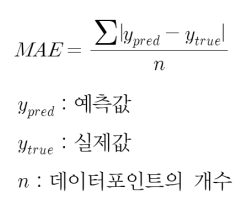

            - 예제계산
                - MAE는 예측값과 실제값 사이의 차이 절대값을 평균한 값, 이 값은 예측값이 실제값과 얼마나 떨어져 있는지를 나타냄
                - 예제 데이터

                    | 데이터 | 실제값 | 예측값 | 오차(예측값 - 실제값) | 절대 오차 |  
                    | :---: | :---: | :---: | :---: | :---: | 
                    | 1 | 50 | 55 | 5 | 5 |
                    | 2 | 60 | 65 | 5 | 5 |
                    | 3 | 70 | 68 | -2 | 2 |

                - 절대 오차의 합: 5 + 5 + 2 = 12
                - 평균: 12 / 3 = 4
                - MAE: 모델의 평균 오차는 4, 즉 모델은 평균적으로 4만큼 오차가 발생

    2. MSE (Mean Squared Error): 평균 제곱 오차
        - MSE는 예측값과 실제값 사이의 오차를 제곱한 뒤 평균을 계산하는 지표
        - 오차를 제곱하기 때문에 큰 오차에 더 민감하게 반응
            - 장점: 큰 오차에 대해 더 높은 패널티를 부여, 모델이 큰 오차를 줄이도록 유도
            - 단점: 오차를 제곱하기 때문에 결과의 단위가 원래 데이터의 단위와 다름
                - ex> 원 단위 데이터라면, MSE는 $(원)^2$ 단위가 됨

                    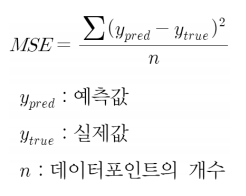

            - 예제계산
                - MSE는 예측값과 실제값 사이의 오차를 제곱한 값의 평균, 오차를 제곱하기 때문에 큰 오차에 더 민감하게 반응

                    | 데이터 | 실제값 | 예측값 | 오차(예측값 - 실제값) | 제곱 오차 |  
                    | :---: | :---: | :---: | :---: | :---: | 
                    | 1 | 50 | 55 | 5 | 25 |
                    | 2 | 60 | 65 | 5 | 25 |
                    | 3 | 70 | 68 | -2 | 4 |

                - 제곱 오차의 합: 25 + 25 + 4 = 54
                - 평균: 54 / 3 = 18
                - MAE: 모델의 평균 제곱 오차는 18, 큰 오차가 발생하면 이 값이 더 커짐

    3. RMSE (Root Mean Squared Error): 평균 제곱근 오차
        - RMSE는 MSE를 제곱근을 취한 값으로 오차를 원래 데이터의 단위로 변환
        - MSE를 해석하기 쉽게 만드는 지표
            - 장점: MSE처럼 큰 오차에 민감하면서도, 단위 문제를 해결
            - 단점: MSE처럼 큰 오차에 지나치케 집중할 수 있음

                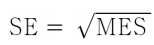

            - RMSE는 MSE의 제곱근을 취한 값으로, MSE의 단위를 실제 데이터 단위로 되돌려 줌
            - 위 MSE 예시 결과에서
            - MSE = 18
            - RMSE = 18의 제곱근을 취해서 4.24
            - RMSE: 평균적으로 약 4.24 정도의 오차가 발생

    4. $R^2$(R-Squared): 결정 계수
        - $R^2$는 모델이 데이터를 얼마나 잘 설명하는 지를 나타내는 지표
        - 1에 가까울수록 모델이 데이터를 잘 설명, 0이면 모델이 데이터를 전혀 설명하지 못함
            - 장점: 모델의 성능을 직관적으로 평가할수 있음
            - 단점: $R^2$가 높다고 항상 모델이 좋은 것은 아님(과적합 가능성)

                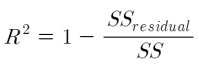

            - 예제계산
                - R-Squared는 모델이 데이터를 얼마나 잘 설명하는 지 평가하는 지표, 1에 가까울수록 모델이 데이터를 잘 설명하고 있다는 의미

                    | 데이터 | 실제값 | 예측값 | 오차(예측값 - 실제값) | 잔차 제곱 |  
                    | :---: | :---: | :---: | :---: | :---: | 
                    | 1 | 50 | 55 | 5 | 25 |
                    | 2 | 60 | 65 | 5 | 25 |
                    | 3 | 70 | 68 | -2 | 4 |

                - 총 변동 계산 (SS total)
                - 실제값의 평균 = (50 + 60 + 70) / 3 = 60
                - 총 변동: $(50 - 60)^2$ + $(60 - 60)^2$ + $(70 - 60)^2$
                - 잔차 제곱 합 (SS residual)
                - 잔차 제곱 = 25 + 25 + 4 = 54
                - R-Squared = 1 - (잔차 제곱 합 / 총 변동)
                - R-Squared = 1 - (54 / 200)
                - R-Squared = 1 - 0.27 = 0.73
                - R-Squared: 모델이 약 73%의 데이터를 잘 설명

